# The Zero-Order-Hold trajectory leg

The Zero-Order-Hold (ZOH, parameterized by the *cut* parameter) trajectory leg is implemented in `pykep` as {class}`pykep.leg.zoh`. The method is described in {cite:p}`izzo2026zoh` as a ZOH $_\alpha$ transcription. Conceptually, it extends the Sims-Flanagan leg by modeling thrust as a piecewise-constant continuous acceleration over each segment, while supporting generic dynamics and nonuniform segment durations.

Given an initial state $\mathbf{x}_0$, a final state $\mathbf{x}_f$, and a time grid $\{t_k\}_{k=0}^{N}$, the leg is partitioned into $N$ segments. On each segment $k$, the control is represented by
$$
\mathbf{u}_k = [T_k,\ i_{x,k},\ i_{y,k},\ i_{z,k}],
$$
where $T_k$ is the throttle magnitude and $(i_{x,k}, i_{y,k}, i_{z,k})$ defines the throttle direction in the selected frame. The full control vector is
$$
\mathbf{u} = [\mathbf{u}_0,\mathbf{u}_1,\ldots,\mathbf{u}_{N-1}].
$$

A forward-backward shooting construction enforces continuity at the matching point, yielding the *mismatch (defect) constraints*. The class provides these constraints and their analytical Jacobians with respect to states, controls, and time-grid variables, making it suitable for gradient-based trajectory optimization (including multiphase and moving-endpoint formulations).

*Throttle constraints*, and corresponding gradients, are also available, in the form $|\mathbf i_k| \le 1 $ 

We start with the required imports:

In [1]:
import pykep as pk
import heyoka as hy
import numpy as np
import pygmo as pg
from copy import deepcopy

#%matplotlib ipympl
%matplotlib inline

In [2]:
# Tolerances used in the numerical integration
# Lower tolerances are faster but less accurate (required tolerance depends on regime).
tol=1e-10
tol_var = 1e-6

# Instantiate ZOH Taylor integrators for Keplerian dynamics (provided by pykep).
# Contract with leg.zoh: state dimension = 7; first 4 parameters are controls;
# variational dynamics are first-order sensitivities w.r.t. state and controls.
ta_global = pk.ta.get_zoh_kep(tol)
ta_var_global = pk.ta.get_zoh_kep_var(tol_var)

# Non-dimensional units (the ZOH Taylor integrator in pykep expects MU=1).
L = pk.AU
MU = pk.MU_SUN
TIME = np.sqrt(L**3/MU)
V =  L/TIME
ACC = V/TIME
MASS = 1000
F = MASS*ACC

# 1 - Validate the Zero-Order-Hold leg
We first validate the implementation by comparing analytical gradients from {class}`pykep.leg.zoh` against finite-difference estimates.

This section also illustrates the standard construction workflow: define boundary states, build controls and time grid, instantiate the leg, then query constraints and Jacobians.

We start with two helper functions used for numerical differentiation:

In [3]:
# These assume some copy of the leg as they will modify it.
def compute_mismatch_constraints_n(leg_mod, state0, controls, state1, tgrid):
   leg_mod.tgrid = tgrid
   leg_mod.state0 = state0
   leg_mod.state1 = state1
   leg_mod.controls = controls
   leg_mod.state1 = state1
   return leg_mod.compute_mismatch_constraints()

def compute_throttle_constraints_n(leg_mod, controls):
    leg_mod.controls = controls
    return leg_mod.compute_throttle_constraints()

We now instantiate a representative leg by selecting the number of segments, the cut, the effective exhaust velocity, and the control vector.

To obtain physically meaningful endpoints, we construct them from a Lambert transfer between two Solar System planets. This choice is only for realism in the example; the method itself is general.

In [4]:
# Create a Lambert leg 
t0 = 10000
t1 = 10400
pl0 = pk.planet(pk.udpla.jpl_lp("Earth"))
pl1 = pk.planet(pk.udpla.jpl_lp("Mars"))
r0, v0 = pl0.eph(t0)
r1, v1 = pl1.eph(t1)
# We create some starting conditions from a Lambert arc
l = pk.lambert_problem(r0=r0, r1=r1, tof = (t1-t0) * pk.DAY2SEC, mu = pk.MU_SUN)
m0 = 1000
m1 = 1000

# leg random data
nseg = int(np.random.uniform(4, 20))
nseg=10
veff = np.random.uniform(4000, 8000) * pk.G0
controls = np.random.uniform(-1,1, (4*nseg,))
controls[0::4] /= (F)  # force will be in [-1, 1] N
controls[0::4] = np.abs(controls[0::4]) # force will be in [0.s, 1] N
cut = np.random.uniform(0,1)

# putting all in nd units
state0 = [it/L for it in r0] + [it/V for it in l.v0[0]] + [m0/MASS]
state1 = [it/L for it in r1] + [it/V for it in l.v1[0]] + [m1/MASS]
veff_nd = veff / V
tgrid = np.linspace(t0*pk.DAY2SEC/TIME, t1*pk.DAY2SEC/TIME, nseg+1)

# Setting the integrator parameters
ta_global.pars[4] = 1. / veff_nd
ta_var_global.pars[4] = 1. / veff_nd

# Instantiate the leg
leg = pk.leg.zoh(state0, controls.tolist(), state1, tgrid, cut = cut, tas = [ta_global, ta_var_global])
#leg = pk.leg.zoh_py(state0, controls.tolist(), state1, tgrid, cut = cut, tas = [ta_global, ta_var_global])

We now compute and store the analytical Jacobians: mismatch-constraint Jacobians and throttle-constraint Jacobian.

In [5]:
grad_an_mc = leg.compute_mc_grad()
tcgrad_an_tc = leg.compute_tc_grad()

... and compare with numerical estimates. We use `pagmo` finite differences as a consistency check.

In [6]:
# Check on dmc/dx0
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, x, leg_copy.controls, leg_copy.state1, leg_copy.tgrid), leg.state0).reshape(7,-1)
np.linalg.norm(grad_num-grad_an_mc[0])

1.7472969614811818e-07

In [7]:
# Check on dmc/dxf
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, leg_copy.state0, leg_copy.controls, x, leg_copy.tgrid), leg.state1).reshape(7,-1)
np.linalg.norm(grad_num-grad_an_mc[1])

3.3313971559876023e-07

In [8]:
# Check on dmc/dcontrols
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, leg_copy.state0, x, leg_copy.state1, leg_copy.tgrid), leg.controls, dx=1e-8).reshape(7,-1)
np.linalg.norm(grad_num-grad_an_mc[2])

2.4101124140165991e-07

In [9]:
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_mismatch_constraints_n(leg_copy, leg_copy.state0, leg_copy.controls, leg_copy.state1, x), leg.tgrid).reshape(7,-1)
np.linalg.norm(grad_num-grad_an_mc[3])

2.5313263390850063e-08

In [10]:
leg_copy = deepcopy(leg)
grad_num = pg.estimate_gradient(lambda x: compute_throttle_constraints_n(leg_copy, x), leg.controls).reshape(nseg,-1)
np.linalg.norm(grad_num-tcgrad_an_tc)

2.9570551748922567e-08

The differences are small and consistent with finite-difference truncation/roundoff errors. In practice, analytical Jacobians are preferable for accuracy and efficiency.

We can now visualize the stitched forward/backward trajectory segments, together with the planetary orbits.

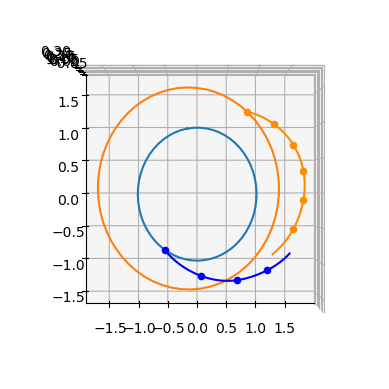

In [11]:
ax = pk.plot.make_3Daxis()
pk.plot.add_planet_orbit(ax, pl0, units=pk.AU)
pk.plot.add_planet_orbit(ax, pl1, units=pk.AU)
fwd, bck = leg.get_state_info(100)
for segment in fwd:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'blue') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue') 
for segment in bck:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'darkorange') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange') 

ax.view_init(90,-90)


# 2 - Use with arbitrary dynamics

A key feature of {class}`pykep.leg.zoh` is that it is not restricted to Keplerian Cartesian dynamics. Any dynamics compatible with the interface can be used (e.g., CR3BP, equinoctial dynamics, higher-fidelity models).

For compatibility with {class}`pykep.leg.zoh`, the dynamics must satisfy:

* State dimension is 7.
* The first four `heyoka` parameters are, in order: `hy.par[0]=T`, `hy.par[1]=i_x`, `hy.par[2]=i_y`, `hy.par[3]=i_z`.
* Variational integrator state dimension is 84, corresponding to 7 state equations plus first-order sensitivities with respect to 7 state variables and 4 control parameters: $7 + 7\times 7 + 7\times 4$.

In `pykep`, compatible integrators are already provided (e.g., {class}`pykep.ta.zoh_kep`, {class}`pykep.ta.zoh_eq`, {class}`pykep.ta.zoh_cr3bp` and their variational counterparts).

Below, for didactic clarity, we explicitly define a CR3BP ZOH dynamics, even though {class}`pykep.ta.zoh_cr3bp` could be used directly.

In [12]:
# The symbolic variables.
[x, y, z, vx, vy, vz, m] = hy.make_vars("x", "y", "z", "vx", "vy", "vz", "m")

# Naming the system controls
T_norm = hy.par[0]
i_x, i_y, i_z = hy.par[1], hy.par[2], hy.par[3]
# Naming the system parameters
# Naming the system parameters
c = hy.par[4]  # 1/veff
mu = hy.par[5]

# Distances to the bodies.
r_1 = hy.sqrt(hy.sum([pow(x + mu, 2.0), pow(y, 2.0), pow(z, 2.0)]))
r_2 = hy.sqrt(hy.sum([pow(x - (1.0 - mu), 2.0), pow(y, 2.0), pow(z, 2.0)]))

# The Equations of Motion.
xdot = vx
ydot = vy
zdot = vz
vxdot = (
    2.0 * vy
    + x
    - (1.0 - mu) * (x + mu) / pow(r_1, 3.0)
    - mu * (x + mu - 1.0) / pow(r_2, 3.0)
    + T_norm * i_x / m
)
vydot = (
    -2.0 * vx
    + y
    - (1.0 - mu) * y / pow(r_1, 3.0)
    - mu * y / pow(r_2, 3.0)
    + T_norm * i_y / m
)
vzdot = -(1.0 - mu) * z / pow(r_1, 3.0) - mu * z / pow(r_2, 3.0) + T_norm * i_z / m
mdot = (
    -c * T_norm * hy.exp(-1.0 / m / 1e16)
)  # the added term regularizes the dynamics keeping it differentiable

dyn = [
    (x, xdot),
    (y, ydot),
    (z, zdot),
    (vx, vxdot),
    (vy, vydot),
    (vz, vzdot),
    (m, mdot),
]

ta_cr3bp = hy.taylor_adaptive(dyn, tol=tol, pars=[0.0, 0.0, 0.0, 0.0, 0.0, 0.01])
vsys = hy.var_ode_sys(
    dyn,
    [x, y, z, vx, vy, vz, m, hy.par[0], hy.par[1], hy.par[2], hy.par[3]],
    1,
)
ta_cr3bp_var = hy.taylor_adaptive(
    vsys,
    tol=tol,
    compact_mode=True,
)


The model is standard CR3BP augmented with thrust acceleration and a (regularized) mass-flow equation. To satisfy the ZOH parameter contract, we reserve `par[0:4]` for thrust controls and use `par[4]`, `par[5]` for additional physical parameters (here $1/v_\mathrm{eff}$ and $\mu$).

As a sanity check, we first propagate a known periodic Lyapunov-orbit initial condition in zero-thrust mode.

In [13]:
mu = 0.01215058560962404
ic = np.array([5.5643551520142581e-02, 9.2420772211102929e-27, 1.3616512785913887e-31, 2.6173746491479341e-12, 5.2390814115699671e+00, 5.3268092625591314e-30, 1000/MASS])
period = 6.301205688481844
ta_cr3bp.pars[4] = 1./veff_nd
ta_cr3bp.pars[5] = mu
ta_cr3bp_var.pars[4] = 1./veff_nd
ta_cr3bp_var.pars[5] = mu

Propagate the system over one period (zero thrust) to verify the setup.

In [14]:
ta_cr3bp.time=0
ta_cr3bp.state[:]=ic
ta_cr3bp.pars[:4] = [0,0,0,0] # No thrust
sol = ta_cr3bp.propagate_grid(np.linspace(0, period,1000))[-1]

Inspect the trajectory to confirm near-periodicity and consistency of the dynamics setup.

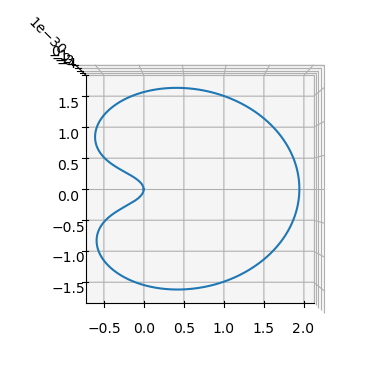

In [15]:
ax = pk.plot.make_3Daxis()
ax.plot(sol[:,0], sol[:,1], sol[:,2])
ax.view_init(90,-90)

Select two points on the orbit to define initial and final boundary states for a ZOH leg.

In [16]:
ts = -period/3
tf = period/5
ta_cr3bp.pars[:4] = [0,0,0,0] # No thrust
ta_cr3bp.propagate_until(tf, 1000)
xf = ta_cr3bp.state.copy()
ta_cr3bp.propagate_until(ts, 1000)
xs = ta_cr3bp.state.copy()

Visualize these two boundary states on the reference trajectory.

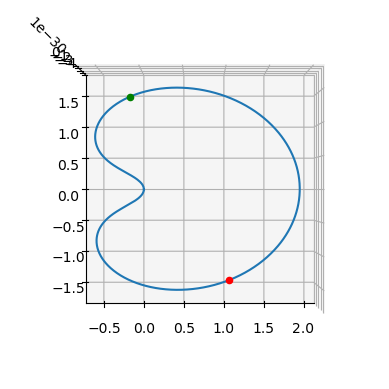

In [17]:
ax = pk.plot.make_3Daxis()
ax.plot(sol[:,0], sol[:,1], sol[:,2])
ax.scatter3D(xs[0], xs[1], xs[2], c='red', s=20)
ax.scatter3D(xf[0], xf[1], xf[2], c='green', s=20)
ax.view_init(90,-90)

Instantiate the ZOH leg in the CR3BP dynamics with the selected boundaries and time grid.

In [18]:
# Instantiate the leg
tgrid = np.linspace(ts, tf, nseg + 1)
controls = [0.0, 0.0, 0.0, 0] * nseg # no thrust
leg_cr3bp = pk.leg.zoh(xs, controls, xf, tgrid, cut=cut, tas=[ta_cr3bp, ta_cr3bp_var])
print("The mismatch constraints are: ", leg_cr3bp.compute_mismatch_constraints())

The mismatch constraints are:  [-4.168110301350225e-12, -5.252465129501616e-13, -1.0881432900098286e-41, -5.813849401903326e-12, 2.1009860518006462e-12, -9.693482126966922e-42, 0.0]


Visualize the forward/backward segment propagation and compare with the reference orbit.

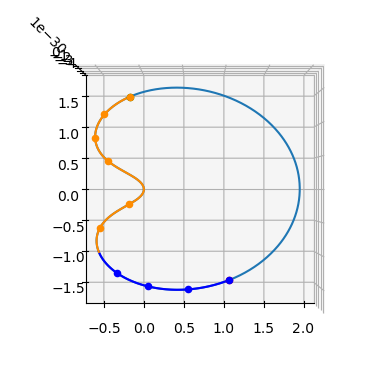

In [19]:
ax = pk.plot.make_3Daxis()
ax.plot(sol[:,0], sol[:,1], sol[:,2])
ax.scatter3D(xs[0], xs[1], xs[2], c='red', s=20)
ax.scatter3D(xf[0], xf[1], xf[2], c='green', s=20)

fwd, bck = leg_cr3bp.get_state_info(N=100)
for segment in fwd:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'blue') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue') 
for segment in bck:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'darkorange') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange') 

ax.view_init(90,-90)

This no-thrust case yields a near-zero mismatch, as expected from consistency with the reference dynamics.

Next, apply non-zero controls to observe how the mismatch changes when boundary states and controls are no longer dynamically consistent.

In [20]:
# Instantiate the leg
tgrid = np.linspace(ts, tf, nseg + 1)
controls = [0.3, 0.1, 0.1, 0] * nseg # no thrust
leg_cr3bp = pk.leg.zoh(xs, controls, xf, tgrid, cut=cut, tas=[ta_cr3bp, ta_cr3bp_var])
print("The mismatch constraints are: ", leg_cr3bp.compute_mismatch_constraints())

The mismatch constraints are:  [-0.08237193006874788, 0.005291237018280492, -1.4514539439469395e-31, 0.086780402871281, 0.06605752972759138, -3.16512818033977e-32, -0.4872013925400698]


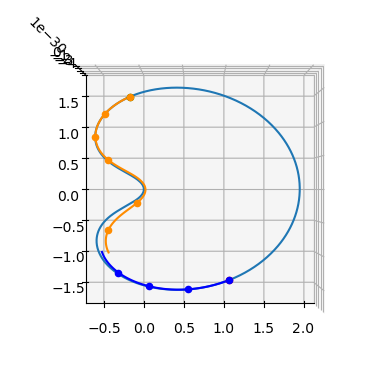

In [21]:
ax = pk.plot.make_3Daxis()
ax.plot(sol[:,0], sol[:,1], sol[:,2])
ax.scatter3D(xs[0], xs[1], xs[2], c='red', s=20)
ax.scatter3D(xf[0], xf[1], xf[2], c='green', s=20)

fwd, bck = leg_cr3bp.get_state_info(N=100)
for segment in fwd:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'blue') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'blue') 
for segment in bck:
    ax.scatter(segment[0,0], segment[0,1], segment[0,2], c = 'darkorange') 
    ax.plot(segment[:,0], segment[:,1], segment[:,2], c= 'darkorange') 

ax.view_init(90,-90)

The result is consistent: introducing non-zero controls with fixed boundaries generally increases mismatch unless controls are optimized.